# 스프린트 미션 15: Docker Hub 실습

## 미션 소개
이번 미션은 두 명의 연구자가 협업하는 아래 시나리오를 참고하여 도커 기반 워크플로우를 설계하고, 
필요한 도커파일을 작성하는 미션입니다.

각 연구자에게 부여된 역할은 다음과 같습니다.

- **연구자 1**: 데이터 전처리, 탐색적 데이터 분석(EDA), 모델링 및 모델 파일 추출
- **연구자 2**: 추출된 모델을 활용한 추론

## 데이터셋
데이터셋의 변수 설명이다.

|변수명|설명|
|---|---|
|Hours Studied|각 학생이 공부에 소요한 총 시간|
|Previous Scores|학생들이 이전 시험에서 얻은 점수|
|Extracurricular Activities|학생이 과외 활동에 참여하는지 여부 (예 또는 아니오)|
|Sleep Hours|학생이 하루 평균 수면 시간|
|Sample Question Papers Practiced|학생이 연습한 모의고사 수|
|Performance Index|**목표변수**. 각 학생의 전반적인 성취도를 나타내는 지표 <br> (성취도 지수는 학생의 학업 성취도를 나타내며, 가장 가까운 정수로 반올림됩니다.<br>지수는 10에서 100까지이며, 값이 높을수록 더 나은 성취도를 나타냅니다.)|

## 협업 시나리오

```text
1. [연구자 1]은 `train.csv` 데이터를 기반으로 Jupyter Notebook(`.ipynb`)에서 
   데이터 전처리, 탐색적 데이터 분석(EDA), 그리고 `scikit-learn`을 사용한 회귀 모델링을 수행한다. 
2. 모델 성능은 RMSE로 평가하며, 최종 모델은 `model.pkl` 파일로 저장한다. 
3. 이후, 전처리 - 모델링 - 모델 저장 과정을 하나의 `.py` 스크립트로 정리한다. 
4. [연구자 1]은 이 작업을 자동화하는 도커 이미지를 구축하여 Docker Hub에 업로드한다.
```

```text
1. [연구자 2]는 [연구자 1]이 생성한 도커 이미지와 별도의 Jupyter Notebook 도커 이미지를 `docker-compose`로 구성한다.
2. [연구자 2]는 [연구자 1]의 도커 컨테이너에서 생성된 `model.pkl` 파일과 컨테이너 내부의 `test.csv` 파일을 활용하여 
   Jupyter Notebook 컨테이너에서 추론을 수행하고, 결과를 `result.csv` 파일로 저장한다. 
3. 전체 추론 과정이 담긴 inference.ipynb 파일을 별도로 저장한다.

(참고: [연구자 2]는 사전에 데이터나 모델 파일을 보유하지 않은 상태이며, 
      [연구자 1]의 Docker Hub 이미지를 통해 필요한 파일을 가져와야 한다.)
```

# 연구자1 분석 코드

## 1. 라이브러리

In [1]:
%pwd

'c:\\codeit_mission\\mission_15'

In [20]:
%pip install seaborn scikit-learn

  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl (38.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle

## 2. 데이터 EDA

In [4]:
train_df = pd.read_csv("./data/mission15_train.csv")
test_df = pd.read_csv("./data/mission15_test.csv")

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   object 
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 328.3+ KB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     3000 non-null   int64 
 1   Previous Scores                   3000 non-null   int64 
 2   Extracurricular Activities        3000 non-null   object
 3   Sleep Hours                       3000 non-null   int64 
 4   Sample Question Papers Practiced  3000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 117.3+ KB


Performance Index가 target인 것 같다.

In [7]:
train_df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

결측 값은 없다.

In [8]:
train_df["Extracurricular Activities"].head()

0     No
1    Yes
2    Yes
3     No
4    Yes
Name: Extracurricular Activities, dtype: object

과외를 참여하면 1, 아니면 0으로 바꿔줘야겠다.

In [11]:
train_df["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     3522
Yes    3478
Name: count, dtype: int64

In [12]:
# 범주형 변수를 수치형 변수로 변환
df = train_df.copy()
df['Extracurricular Activities'] = df['Extracurricular Activities'].apply(lambda x: 1 if x == 'Yes' else 0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   int64  
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 328.3 KB


In [13]:
df["Extracurricular Activities"].value_counts()

Extracurricular Activities
0    3522
1    3478
Name: count, dtype: int64

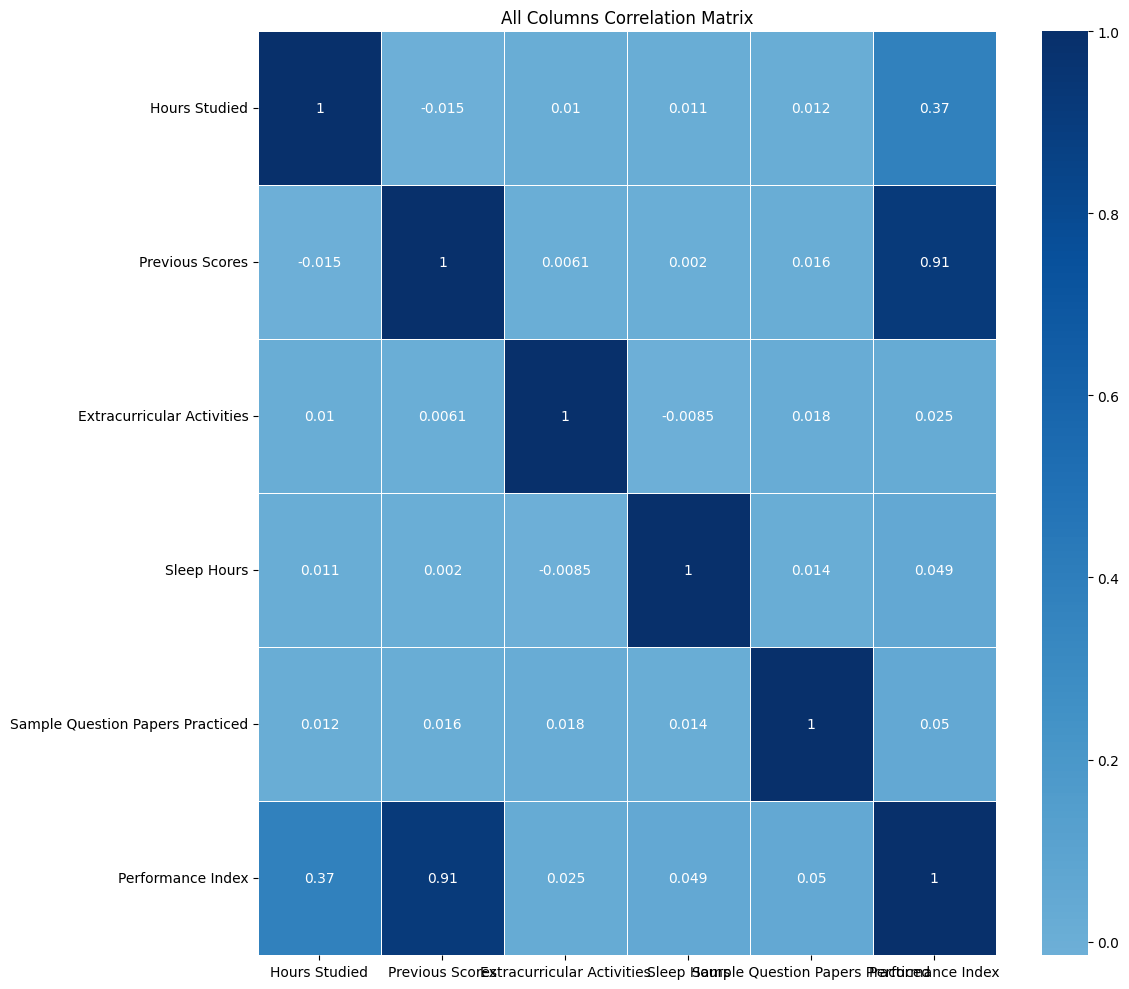

In [ ]:
# 상관행렬 계산
corr_matrix = df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            cmap='Blues',
            annot=True,
            center=0,
            linewidths=0.5)       # 셀 경계선
plt.title('All Columns Correlation Matrix')
plt.xticks(rotation=360)
plt.yticks(rotation=360)
plt.tight_layout()
plt.show()

Previous Scores 가 상관관계가 가장 높았다. Previous Scores, Performance Index, Hours Studied의 분포를 확인해볼 필요가 있다.

In [15]:
df["Performance Index"].value_counts()

Performance Index
49.0     137
47.0     127
41.0     127
45.0     124
74.0     123
        ... 
11.0       4
12.0       4
100.0      2
99.0       2
10.0       1
Name: count, Length: 91, dtype: int64

In [17]:
col_list = df.columns.tolist()
print(col_list)

['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


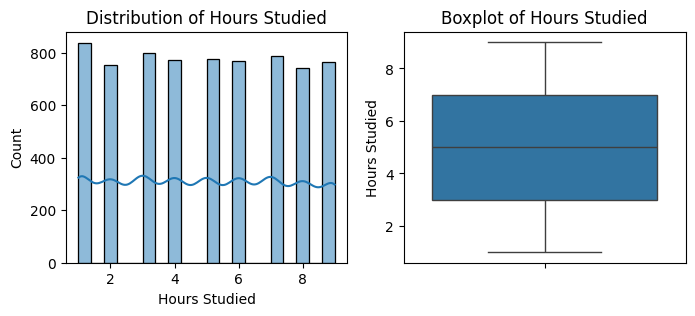

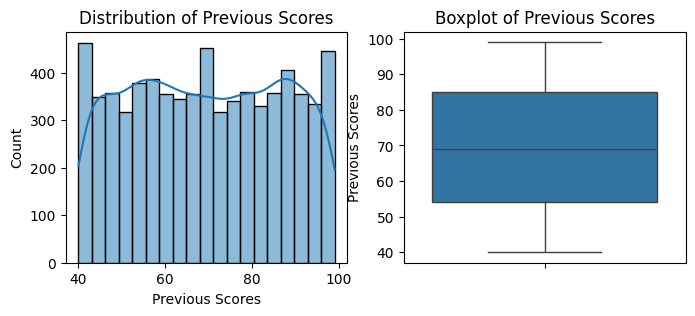

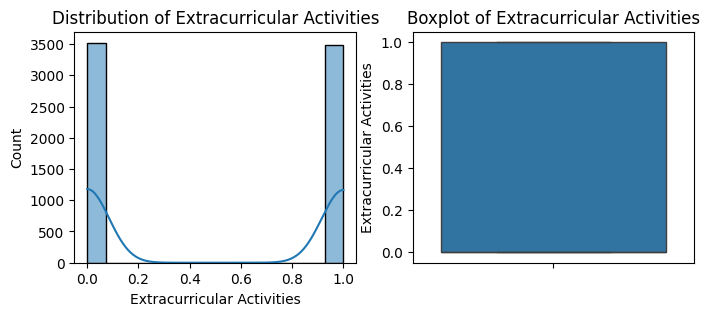

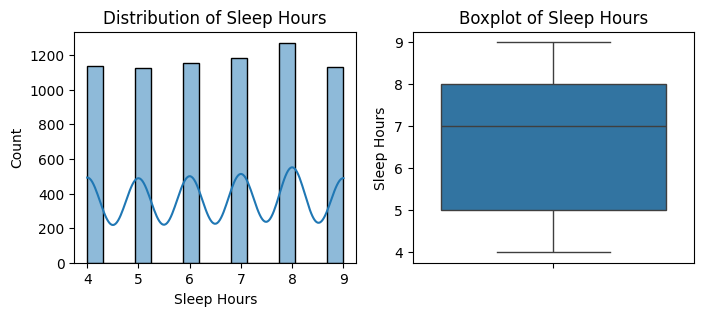

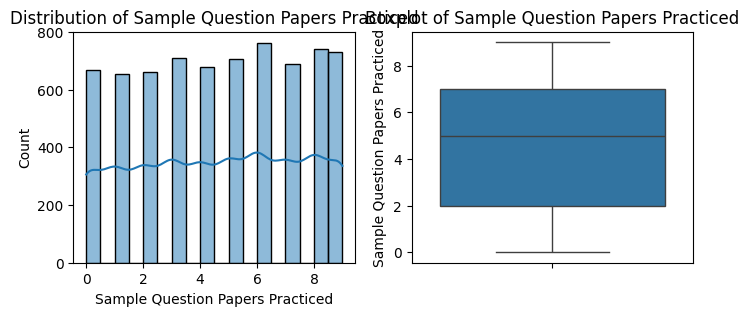

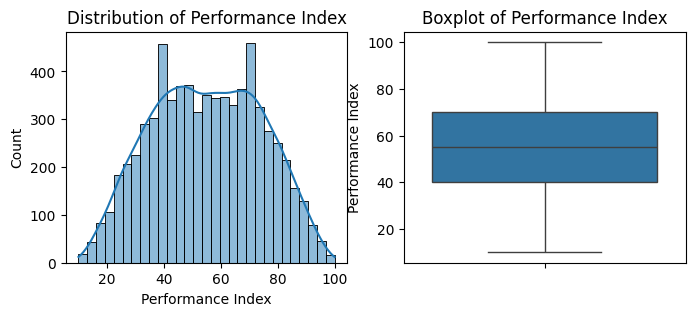

In [18]:
for feature in col_list:
    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], kde=True)
    plt.title('Distribution of ' + feature)
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[feature])
    plt.title('Boxplot of ' + feature)
    plt.show()

모든 데이터가 사분위수 내에 들어가있다. 데이터의 분포 역시 균일하고 Target은 정규분포와 유사한 모양을 보인다.

## 3. 전처리

In [23]:
# 독립, 종속 변수 선언
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

# 훈련, 평가 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. 모델링

In [24]:
# 모델 훈련
model = LinearRegression()
model.fit(X_train,y_train)

valid = model.predict(X_valid)

In [28]:
rmse = np.sqrt(mean_squared_error(y_valid, valid))
print(f"RMSE: {rmse:.4f}")

RMSE: 2.0103


## 5. 평가 결과 확인 및 개선점 확인

<Axes: ylabel='None'>

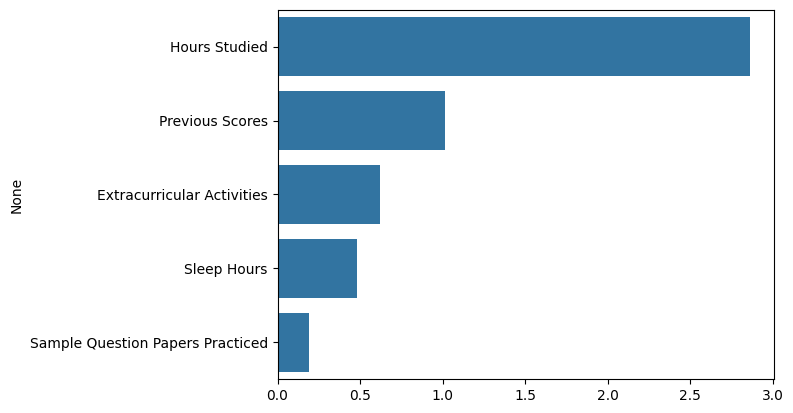

In [29]:
coef = pd.Series(model.coef_, index = X.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

초기 RMSE는 2.0103이고 가장 영향을 끼친 것은 'Hours Studied'이다. 

In [30]:
print(model.coef_)

[2.86273185 1.01629014 0.62339038 0.48269347 0.19129646]


In [31]:
print(model.intercept_)

-33.977830090365124


기존 예측에서는 Previous Scores가 큰 영향을 줄 것으로 예측 되었지만 Hours Studied가 중요도가 가장 높게 나왔다.

결과의 원인은 두 변수의 범위와 변수가 다르기 때문이다. Standardized Coefficient로 바꾸거나 StandardScaler를 해주면 예상했던 결과가 나올 것 같다.

In [33]:
df2 = df.copy()

# 변수 정규화
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df2.drop("Performance Index", axis=1))
df_scaled = pd.DataFrame(scaled_features, columns=df2.columns[:-1])

In [36]:
# 독립, 종속 변수 선언
X = df_scaled
y = df2["Performance Index"]

# 훈련, 평가 데이터 분할
X2_train, X2_valid, y2_train, y2_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# 모델 훈련
model2 = LinearRegression()
model2.fit(X2_train,y2_train)

valid2 = model2.predict(X2_valid)

In [38]:
rmse2 = np.sqrt(mean_squared_error(y2_valid, valid2))
print(f"RMSE: {rmse2:.4f}")

RMSE: 2.0103


<Axes: ylabel='None'>

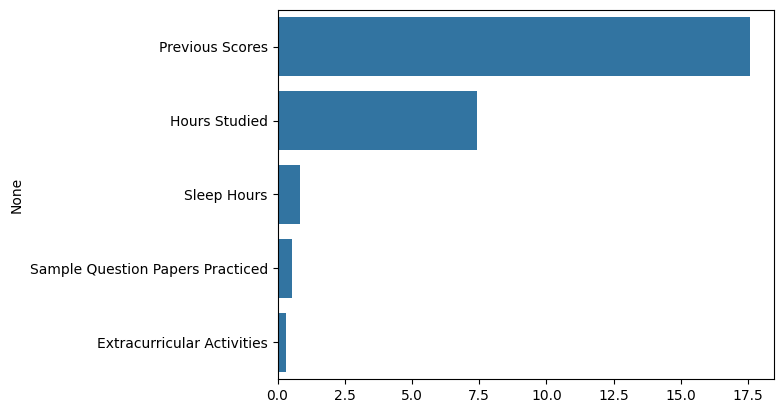

In [39]:
coef = pd.Series(model2.coef_, index = X.columns)
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

예측한대로 바뀌었다.

## 6. 결과 저장

In [41]:
with open('./models/best_linear_model.pkl', 'wb') as f:
    pickle.dump(model2, f)